In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

##Load data

In [2]:
# Preprocess data
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

#overview of the data
df = pd.DataFrame(wine.data, columns=wine.feature_names)
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [3]:
# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply Clustering (Before PCA)

###Elbow method to choose k

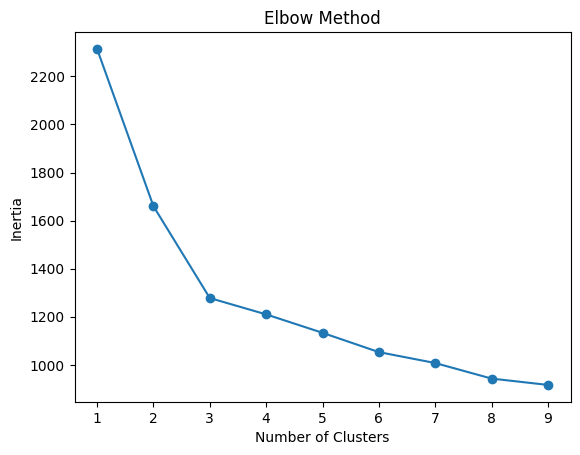

In [4]:
inertia = []

for k in range(1,10):

    model = KMeans(n_clusters=k)
    model.fit(X_scaled)

    inertia.append(model.inertia_)
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

##K-mean clustring before PCA

In [5]:
# We use 4 clusters
kmeans_before = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_before = kmeans_before.fit_predict(X_scaled)
score_before = silhouette_score(X_scaled, labels_before)

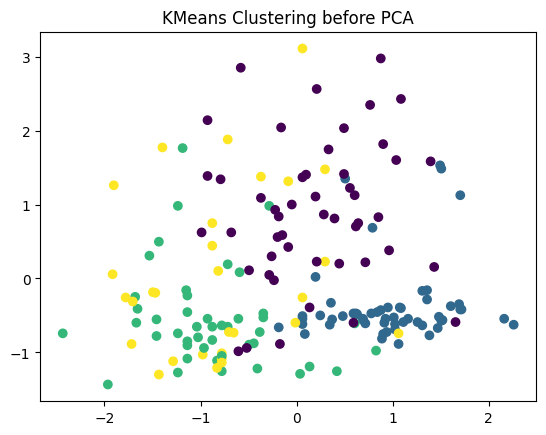

In [6]:
#vizualize clusters
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_before, cmap="viridis")
plt.title("KMeans Clustering before PCA")
plt.show()

##K-mean clustring after PCA

In [7]:
#After PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(178, 2)


In [8]:
kmeans_after = KMeans(n_clusters=4)

clusters_pca = kmeans_after.fit_predict(X_pca)

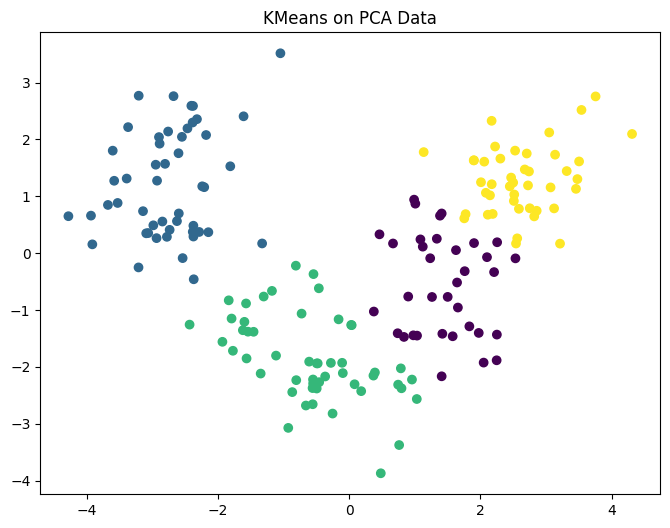

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca, cmap="viridis")
plt.title("KMeans on PCA Data")
plt.show()

In [10]:
pca.explained_variance_ratio_.sum()

np.float64(0.5540633835693526)




*    PCA reduces dimensionality, removing noise and redundant features.
*   Clustering after PCA often becomes more stable but may slightly reduce accuracy.

*   the visualization become more cleare.
*   the result of (pca.explained_variance_ratio_.sum()) is 0.5 so we lose 50% of information.

*  For visualization PCA is better, For accuracy original data may be slightly better since we lose 50% of the information.



#Bonus part

## 1. DBSCAN

In [11]:
for eps in [1.9, 2.0, 2.1, 2.2, 2.3]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps}, clusters={n_clusters}, noise={n_noise}")

eps=1.9, clusters=6, noise=103
eps=2.0, clusters=5, noise=85
eps=2.1, clusters=3, noise=62
eps=2.2, clusters=2, noise=55
eps=2.3, clusters=2, noise=42


###DBSCAN before PCA

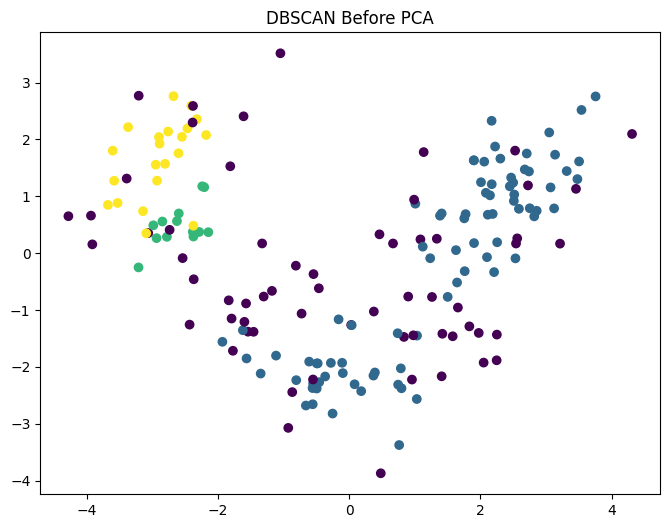

In [12]:
# before pca
dbscan_before = DBSCAN(eps=2.1, min_samples=5)
labels_before = dbscan_before.fit_predict(X_scaled)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_before, cmap='viridis')
plt.title("DBSCAN Before PCA") # but (visualized with PCA)
plt.show()

###DBSCAN after PCA

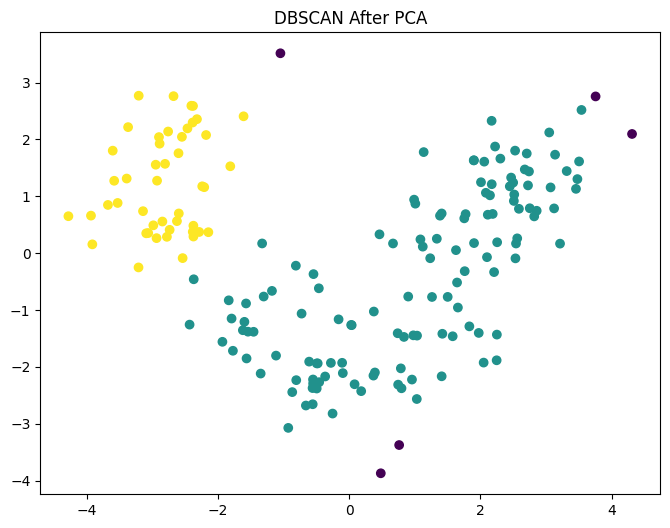

In [13]:
# after pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dbscan_after = DBSCAN(eps=0.8, min_samples=5)  #tuned eps
labels_after = dbscan_after.fit_predict(X_pca)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_after, cmap='viridis')
plt.title("DBSCAN After PCA")
plt.show()


In [14]:
#Evaluate with Silhouette Score
score = silhouette_score(X_scaled,labels_before )
print("Silhouette Score befor PCA:", score)

score_after = silhouette_score(X_pca, labels_after)
print("Silhouette Score after PCA:", score_after)

Silhouette Score befor PCA: 0.04858047468707052
Silhouette Score after PCA: 0.3778089439198992


DBSCAN found 3 clusters in the Wine dataset, but some points were treated as noise(almost 5 points). Silhouette score was very low before PCA ~0.05 and improved after PCA to 0.38.

##2. Try different number of PCA components

In [15]:
for n in [3, 5, 7]:
    pca = PCA(n_components=n)
    X_pca_n = pca.fit_transform(X_scaled)

    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(X_pca_n)

    print(f"Components: {n}, Silhouette Score: {silhouette_score(X_pca_n, labels)}")

Components: 3, Silhouette Score: 0.4537999848257614
Components: 5, Silhouette Score: 0.36907631946992303
Components: 7, Silhouette Score: 0.32763517224028227


The best clustering performance was achieved with 3 PCA components, as it produced the highest Silhouette Score, while increasing the number of components reduced clustering quality.

##3. Extra part: HDBSCAN

*   DBSCAN has many advanges but its Sensitive to (ε) and minPts parameters.

*   HDBSCAN (Hierarchical DBSCAN) is the clustering algorithm that keeps the advantages of DBSCAN, by removing the need to decide on the value of ϵ.

*   The algorithm is capable of building clusters of varying density.
*   HDBSCAN only has one important hyperparameter: n, the minimum number of examples to put in a cluster.
    *   List itemThis hyperparameter is relatively simple to choose by intuition.
*   HDBSCAN has very fast implementations
    *   It can deal with millions of examples effectively.

In [16]:
!pip install hdbscan

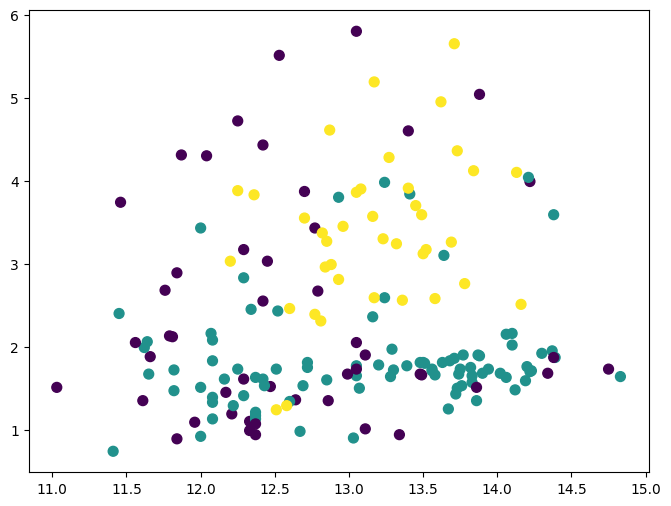

In [17]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=3)
cluster_labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, s=50, cmap='viridis')
plt.show()

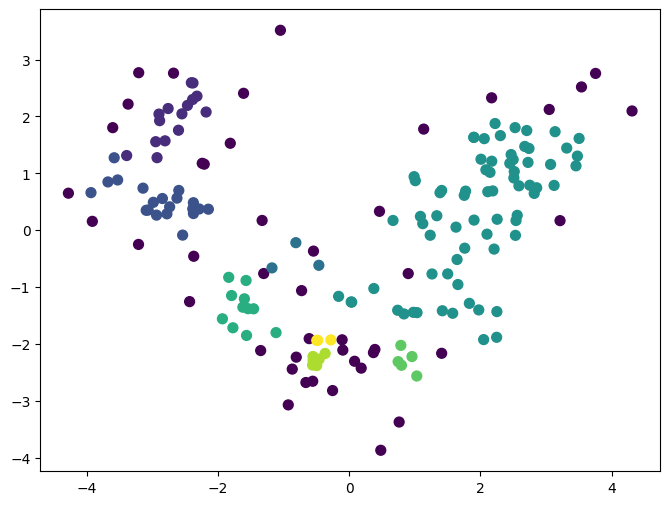

In [18]:
cluster_labels = clusterer.fit_predict(X_pca)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=50, cmap='viridis')
plt.show()